In [5]:
import os

# Trick to plot with tex on candide
os.environ["LD_LIBRARY_PATH"] = ""
os.environ["CONDA_PREFIX"] = "/home/guerrini/.conda/envs/sp_validation_3.11"

import numpy as np
from astropy.io import fits
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

import seaborn as sns
from getdist import plots, MCSamples

from shear_psf_leakage.rho_tau_stat import RhoStat, TauStat, PSFErrorFit

plt.style.use(
    "./matplotlib_config/paper.mplstyle"
)

plt.rcParams["text.usetex"] = True

sns.set_palette("husl")

%matplotlib inline

g = plots.get_subplot_plotter()

g.settings.legend_fontsize = 10
g.settings.axes_fontsize=10

def cov_to_corr(cov):
    """Convert a covariance matrix to a correlation matrix."""
    d = np.sqrt(np.diag(cov))
    corr = cov / np.outer(d, d)
    corr[cov == 0] = 0
    return corr

In [1]:
data_path = "/home/guerrini/sp_validation/cosmo_inference/data/"

path_cosmo_val = "/home/guerrini/sp_validation/notebooks/cosmo_val/output/"

versions = ["SP_v1.4.6", "SP_v1.4.6_leak_corr"]
roots = [
    "SP_v1.4.6_no_leak_corr_A_masked",
    "SP_v1.4.6_leak_corr_A_masked"
] #Root name of the cosmosis data vector used
labels = ["No leakage correction", "With leakage correction"]
colors = ["C0", "C1"]

In [4]:
data_vectors = []

for root in roots:
    data_vectors.append(
        fits.open(data_path + root +f"/cosmosis_{root}.fits")
    )

In [6]:
#Create dummy rho and tau stat handler.

#Inference of the xi_sys parameters
sep_units = 'arcmin'
coord_units = 'degrees'
theta_min = 1.0
theta_max = 250
nbins = 20


TreeCorrConfig_xi = {
    'ra_units': coord_units,
    'dec_units': coord_units,
    'min_sep': theta_min,
    'max_sep': theta_max,
    'sep_units': sep_units,
    'nbins': nbins,
    'var_method':'jackknife',
}

rho_stats_handler = RhoStat(
    output='.',
    treecorr_config=TreeCorrConfig_xi,
    verbose=True
)

tau_stats_handler = TauStat(
    catalogs=rho_stats_handler.catalogs,
    output='.',
    treecorr_config=TreeCorrConfig_xi,
    verbose=True
)

In [7]:
#Write a function to load the covariance and cut it to only use alpha and beta
def load_matrix_and_cut(root, root_cosmo_val, type='rho'):
    if type=='rho':
        cov = np.load(f"{root}/cov_rho_{root_cosmo_val}.npy")
        nbins = cov.shape[0] // 6
        cov = cov[:nbins*3, :nbins*3]
        np.save(f"{root}/cov_rho_{root_cosmo_val}_cut.npy", cov)
    elif type=='tau':
        cov = np.load(f"{root}/cov_tau_{root_cosmo_val}_th.npy")
        nbins = cov.shape[0] // 3
        cov = cov[:nbins*2, :nbins*2]
        np.save(f"{root}/cov_tau_{root_cosmo_val}_th_cut.npy", cov)
    else:
        raise ValueError("type must be 'rho' or 'tau'")

In [9]:
#Create a PSFErrorFit instance
psf_fitter = PSFErrorFit(rho_stats_handler, tau_stats_handler, path_cosmo_val+'rho_tau_stats/', use_eta=False)

chains = []

#Load rho-, tau-statistics, and cov_tau from the data_vector
for i, root_cosmo_val in enumerate(versions):
    print("Sampling PSF parameters for ", labels[i])
    path_rho = f"rho_stats_{root_cosmo_val}.fits"
    path_tau = f"tau_stats_{root_cosmo_val}.fits"
    path_cov_rho = f"cov_rho_{root_cosmo_val}.npy"
    path_cov_tau = f"cov_tau_{root_cosmo_val}_th.npy"

    load_matrix_and_cut(path_cosmo_val+'/rho_tau_stats/', root_cosmo_val, type='rho')
    load_matrix_and_cut(path_cosmo_val+'/rho_tau_stats/', root_cosmo_val, type='tau')
    path_cov_rho = f"cov_rho_{root_cosmo_val}_cut.npy"
    path_cov_tau = f"cov_tau_{root_cosmo_val}_th_cut.npy"

    psf_fitter.load_rho_stat(path_rho)
    psf_fitter.load_tau_stat(path_tau)
    psf_fitter.load_covariance(path_cov_rho, cov_type='rho')
    psf_fitter.load_covariance(path_cov_tau, cov_type='tau')
    samples_lq, _, _ = psf_fitter.get_least_squares_params_samples(npatch=None, apply_debias=False)

    samples_gd = MCSamples(samples=samples_lq, names=[r"\alpha", r"\beta"], labels=[r"\alpha", r"\beta"])

    chains.append(samples_gd)

Class created. Don't forget to load your rho and tau statistics and define your prior and your likelihood.
Sampling PSF parameters for  No leakage correction


100%|██████████| 10000/10000 [00:35<00:00, 284.72it/s]


Number of samples: 10000

Parameters constraints
----------------------
Parameter: $\alpha$=0.0222^+0.0026_0.0026
Parameter: $\beta$=0.7703^+0.1131_0.1144
Chi square: 72.57480636040468
Removed no burn in
Sampling PSF parameters for  With leakage correction


100%|██████████| 10000/10000 [00:33<00:00, 298.71it/s]

Number of samples: 10000

Parameters constraints
----------------------
Parameter: $\alpha$=0.0050^+0.0021_0.0021
Parameter: $\beta$=0.8063^+0.1082_0.1144
Chi square: 70.17303691323765
Removed no burn in


/home/guerrini/.conda/envs/sp_validation_3.11/lib/python3.11/site-packages/getdist/plots.py:3347: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  self.fig.savefig(fname, bbox_extra_artists=self.extra_artists, bbox_inches='tight', **kwargs)
/home/guerrini/.conda/envs/sp_validation_3.11/lib/python3.11/site-packages/IPython/core/events.py:82: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  func(*args, **kwargs)
/home/guerrini/.conda/envs/sp_validation_3.11/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.canvas.print_figure(bytes_io, **kw)


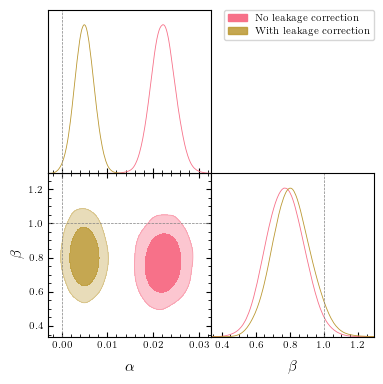

In [11]:
g = plots.get_subplot_plotter()

g.settings.legend_fontsize = 10
g.settings.axes_fontsize=10

markers = {
    r"\alpha": 0.0,
    r"\beta": 1.0,
}

line_args = [
    {'color': colors[i]} for i in range(len(versions))
]
g.triangle_plot(
    chains,
    filled=True,
    legend_labels=labels,
    legend_loc="upper right",
    line_args=line_args,
    contour_colors=colors,
    markers=markers
)

ax = g.get_axes(ax=(1, 0))
ax.minorticks_on()
ax = g.get_axes(ax=(1, 1))
ax.minorticks_on()
ax.get_yaxis().set_visible(False)
g.export("./plots/psf_leakage_prior.pdf")

In [24]:
# Check that the prediction for the xi_sys is consistent with the (alpha, beta, eta) fit
xi_sys_samples = []
for i, root_cosmo_val in enumerate(versions):
    print("Predicting xi_sys for ", labels[i])
    samples = chains[i].samples

    path_rho = f"rho_stats_{root_cosmo_val}.fits"
    path_tau = f"tau_stats_{root_cosmo_val}.fits"
    
    psf_fitter.load_rho_stat(path_rho)
    psf_fitter.load_tau_stat(path_tau)

    xi_sys_sample = np.array([
        psf_fitter.compute_xi_psf_sys(sample) for sample in samples
    ])

    xi_sys_samples.append(xi_sys_sample)

xi_sys_samples_eta = []
psf_fitter_eta = PSFErrorFit(
    rho_stats_handler, tau_stats_handler, path_cosmo_val+'rho_tau_stats/', use_eta=True
)
for i, root_cosmo_val in enumerate(versions):
    print("Predicting xi_sys with eta for ", labels[i])
    # Load the saved samples
    samples_eta = np.load(f"{path_cosmo_val}/rho_tau_stats/samples_{root_cosmo_val}.npy")

    # Load the rho and tau statistics
    path_rho = f"rho_stats_{root_cosmo_val}.fits"
    path_tau = f"tau_stats_{root_cosmo_val}.fits"
    
    psf_fitter.load_rho_stat(path_rho)
    psf_fitter.load_tau_stat(path_tau)

    # Compute the xi_sys
    xi_sys_sample_eta = np.array([
        psf_fitter_eta.compute_xi_psf_sys(sample) for sample in samples_eta
    ])
    xi_sys_samples_eta.append(xi_sys_sample_eta)


Predicting xi_sys for  No leakage correction
Predicting xi_sys for  With leakage correction
Class created. Don't forget to load your rho and tau statistics and define your prior and your likelihood.
Predicting xi_sys with eta for  No leakage correction
Predicting xi_sys with eta for  With leakage correction


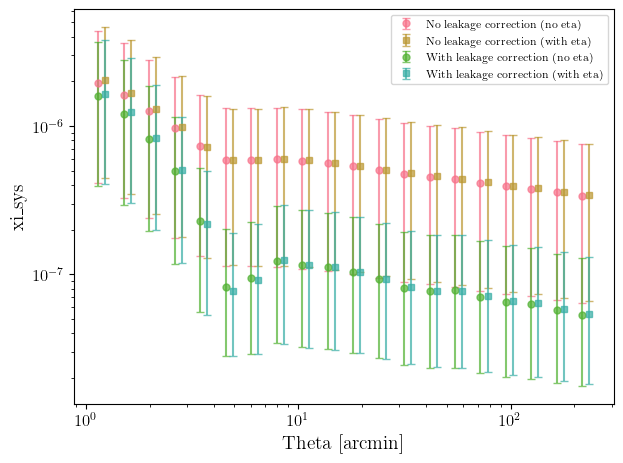

In [34]:
plt.figure()

#offset of the points
offset = 0.08

for i, label in enumerate(labels):
    xi_sys_low, xi_sys_med, xi_sys_up = np.quantile(
        xi_sys_samples[i], [0.16, 0.5, 0.84], axis=0
    )

    xi_sys_eta_low, xi_sys_eta_med, xi_sys_eta_up = np.quantile(
        xi_sys_samples_eta[i], [0.16, 0.5, 0.84], axis=0
    )

    theta_bins = rho_stats_handler.rho_stats['theta']

    jittered_theta = theta_bins * (1 + offset)

    plt.errorbar(
        theta_bins,
        xi_sys_med,
        yerr=[xi_sys_low, xi_sys_up],
        label=f"{label} (no eta)",
        fmt='o',
        capsize=3,
        markersize=5,
        alpha=0.7
    )

    plt.errorbar(
        jittered_theta,
        xi_sys_eta_med,
        yerr=[xi_sys_eta_low, xi_sys_eta_up],
        label=f"{label} (with eta)",
        fmt='s',
        capsize=3,
        markersize=5,
        alpha=0.7
    )

plt.xlabel("Theta [arcmin]")
plt.ylabel("xi_sys")

plt.xscale('log')
plt.yscale('log')

plt.legend()

plt.savefig("./plots/xi_sys_prediction_vs_eta.png")
plt.show()